In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

## Opgave 1. (10 point) Lad $A$ være matricen
$$
\begin{bmatrix}
1 & 0 & 0 \\
0 & -2 & 0 \\
0 & 0 & 3
\end{bmatrix}
$$
Bestem singulærværdierne for 𝐴 uden brug af python. 

Da A allerede er en diagonal matrix, holder den selv på alle sine singulærværdier. Ifølge sætning 10.2 skal $\lambda \geq 0$, så den numeriske værdi tages. Svaret er da A (3, 2, 1).

## Opgave 2. (10 point) Betragt den reelle matrix:
$$
A
=
\begin{bmatrix}
1 & 2 & 3 \\
1 & 2 & 3 \\
0 & 1 & 1
\end{bmatrix}
$$
Bestem søjlerummet for 𝐴.

In [2]:
A = np.array([[1, 2, 3],
              [1, 2, 3],
              [0, 1, 1]])

A[1] -= A[0]
A[[1,2], :] = A[[2,1], :]
A

array([[1, 2, 3],
       [0, 1, 1],
       [0, 0, 0]])

Det kan ses at matricens pivotsøjler er søjlerne nul og et, hvilket betyder at søjlerummet udspændes af (1,1,0) og (2,2,1). Svaret er dermed C.

## Opgave 3. (10 point) Hvis en $(n \times n)$-matrix $A$, har 0 som egenværdi hvad kan man så sige om $A$?

Ifølge proposition 21.2 af notesættet er $\lambda$ en egenværdi hvis og kun hvis $A - \lambda I_{n}$ er ikke invertibel. Da $\lambda$ er 0, vil det svare til at $A$ skal være ikke invertibel. Når en matrix er ikke invertibel siges den at være singulær. Svaret er dermed B.

## Opgave 4. (10 point) Lad 𝐴,𝐵,𝐶 være matricer med $A \in \mathbb{R}^{5 \times 1000}$, $B \in \mathbb{R}^{1000 \times 200}$ og $C \in \mathbb{R}^{200 \times 10}$. Hvilke af de følgende matrixberegninger kræver færrest flops, og hvor mange flops bruges der for denne beregning? (i) 𝐴(𝐵𝐶) eller (ii) (𝐴𝐵)𝐶.

In [3]:
# Funktion defineret ud fra matrixprodukt omkostning fra tabel 5.1 i notesættet
def product_flops(M1,M2):
    S1 = M1.shape
    S2 = M2.shape
    return S1[0] * S2[1] * 2 * S2[0]

In [4]:
A = np.ones((5,1000))
B = np.ones((1000,200))
C = np.ones((200,10))

# antal flops fra A(BC)
product_flops(A, B@C) + product_flops(B, C)

4100000

In [5]:
# antal flops af (AB)C
product_flops(A, B) + product_flops(A@B, C)

2020000

Det kan ses at (ii) (AB)C kun bruger 2020000 flops, hvilket gør det til den der kræver færrest flops.

## Opgave 5. (20 point) Betragt vektorerne
$$
v_{0} =
\begin{bmatrix}
2.0 \\
2.0 \\
-2.0 \\
-2.0
\end{bmatrix}
, \qquad
v_{1} =
\begin{bmatrix}
1.0 \\
-1.0 \\
1.0 \\
-1.0
\end{bmatrix}
, \qquad
v_{2} =
\begin{bmatrix}
0.0 \\
3.0 \\
3.0 \\
0.0
\end{bmatrix}
$$
i $\mathbb{R}^{4}$.

### (a) I python dan Grammatricen for $v_{0}$, $v_{1}$, $v_{2}$ og bekræft at denne samling vektorer er ortogonal.

In [6]:
# Grammatricen dannes på baggrund af afsnit 9.3 i notesættet
v0 = np.array([2.0, 2.0, -2.0, -2.0])[:, np.newaxis]
v1 = np.array([1.0, -1.0, 1.0, -1.0])[:, np.newaxis]
v2 = np.array([0.0, 3.0, 3.0, 0.0])[:, np.newaxis]

V = np.column_stack((v0, v1, v2))
G = V.T @ V
G

array([[16.,  0.,  0.],
       [ 0.,  4.,  0.],
       [ 0.,  0., 18.]])

Det kan ses at alle værdierne udenfor diagonalen er 0. I en grammatrix svarer det til at vektorsamlingen er ortogonal, da den $(i,j)$'te indgang er det indre produkt mellem $v_{i}$ og $v_{j}$ (jvf. afsnit 9.3 af notesættet).

### (b) Beregn projektionen 𝑃𝑥 af
$$
x =
\begin{bmatrix}
0.0 \\
1.0 \\
2.0 \\
3.0
\end{bmatrix}
$$
langs $v_{0}$, $v_{1}$, $v_{2}$.

In [8]:
# Projektionen beregnes efter definition 8.19 i notesættet
x = np.array([0.0, 1.0, 2.0, 3.0])[:, np.newaxis]

P = (v0 @ v0.T) / np.linalg.norm(v0)**2 + (v1 @ v1.T) / np.linalg.norm(v1)**2 + (v2 @ v2.T) / np.linalg.norm(v2)**2
print("Den projecerede vektor, Px, er:\n", P @ x)

Den projecerede vektor, Px, er:
 [[-1.5]
 [ 1. ]
 [ 2. ]
 [ 1.5]]


### (c) Bekræft at $v_{3} := x - Px$ er ortogonal til $v_{0}$, $v_{1}$ og $v_{2}$.

In [9]:
v3 = x - P@x
V_ny = np.column_stack([V, v3])

G_ny = V_ny.T @ V_ny
print(G_ny)

[[ 1.60000000e+01  0.00000000e+00  0.00000000e+00 -4.44089210e-16]
 [ 0.00000000e+00  4.00000000e+00  0.00000000e+00  2.22044605e-16]
 [ 0.00000000e+00  0.00000000e+00  1.80000000e+01 -6.66133815e-16]
 [-4.44089210e-16  2.22044605e-16 -6.66133815e-16  4.50000000e+00]]


Det kan ses at 

### (d) Brug $v_{0}$, $v_{1}$, $v_{2}$, $v_{3}$ til at bestemme en ortonormal basis for $\mathbb{R}^{4}$.

In [10]:
# Samlingen kan gøres ortonormal ved at dele vektorerne med deres længder 
V_normal = np.column_stack([v0/np.linalg.norm(v0), v1/np.linalg.norm(v1), 
                            v2/np.linalg.norm(v2), v3/np.linalg.norm(v3)])

# Værdierne i vektorsamlingen afrundes for nemmere læsbarhed
print("Den ortonormale basis for R⁴ vil være:\n", np.round(V_normal,4))

Den ortonormale basis for R⁴ vil være:
 [[ 0.5     0.5     0.      0.7071]
 [ 0.5    -0.5     0.7071 -0.    ]
 [-0.5     0.5     0.7071  0.    ]
 [-0.5    -0.5     0.      0.7071]]


## Opgave 6. (20 point) Betragt de følgende datapunkter

| t   | 0.1 | 1.9 | 3.1 | 4.5 | 6.2 | 7.1 |
| --- | --- | --- | --- | --- | --- | --- |
| h   | 0.2 | 1.1 | 1.9 | 2.0 | 2.2 | 1.7 |

Der ønskes et tredjeordenspolynomium $pt^{3} + qt^{2} + rt + s$ der går igennem
punkterne.

### (a) Forklar hvordan dette svarer til at løse et lineært ligningssystem $Ax = b$ og hvorfor man kan ikke forvente en eksakt løsning.

In [11]:
t_data = np.array([0.1, 1.9, 3.1, 4.5, 6.2, 7.1])
A = np.vander(t_data, 4)
A.shape

(6, 4)

Det kan ses at der er flere rækker en søjler, hvilket vil sige at man ikke kan forvente en eksakt løsning, som rammer alle datapunkter med kun en tredjegradspolynomium. 

### (b) Brug python til at bestemme singulærværdierne af a og konditionstallet 𝜅(𝐴).

In [12]:
u, s, vt = np.linalg.svd(A, full_matrices=False)

print("Singulærværdierne er:", s)

# ligning 11.10 i notesættet
kA = s[0] / s[-1]

print("k(A) er:", kA)

Singulærværdierne er: [445.74654805  10.45244746   1.3583455    0.57387607]
k(A) er: 776.7296257121553


### (c) Ved brug af singulærværdidekomponering, bestem i python den mindste kvadraters løsning til systemet $A x = b$.

In [13]:
# Singulærværdidekomponeringen samt b indsættes i ligning 16.5 fra notesættet
h_data = np.array([0.2, 1.1, 1.9, 2.0, 2.2, 1.7])[:, np.newaxis]
X = vt.T @ np.linalg.inv(np.diag(s)) @ u.T @ h_data
X

array([[-0.00934156],
       [ 0.02254745],
       [ 0.53607127],
       [ 0.13819423]])

### (d) Giv en python plot af datapunkterne og det tredjeordenspolynomium bestemt af din løsning til del (c).

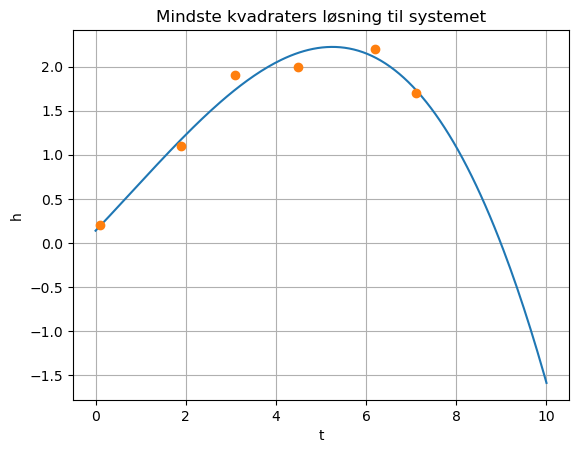

In [14]:
t = np.linspace(0, 10, 200)
h = X[0]*t**3 + X[1]*t**2 + X[2]*t + X[3]

fig, ax = plt.subplots()
ax.plot(t, h)
ax.plot(t_data, h_data, "o")
ax.set_xlabel('t')
ax.set_ylabel('h')
ax.set_title('Mindste kvadraters løsning til systemet')
ax.grid()

## Opgave 7. (20 point) Betragt matricen
$$
A =
\begin{bmatrix}
2 & 0 & 2 \\
0 & 3 & 0 \\
1 & 0 & 3
\end{bmatrix}
$$
I denne opgave må der ikke bruges python funktioner, som f.eks. np.linalg.eig, der beregne egenværdier og/eller egenvektorer.

### (a) Bestem det karakteristiske polynomium $\text{det}(𝐴 - 𝜆 𝐼_{3})$ af 𝐴.

Det karakteristiske polynomium sættes op som vist i afsnit 21.5 af notesættet.
\begin{align*}
\text{det}(A - \lambda I_{3}) & = \text{det}\left( \begin{bmatrix}
2 - \lambda & 0 & 2 \\
0 & 3 - \lambda & 0 \\
1 & 0 & 3 - \lambda
\end{bmatrix} \right)\\
 & = (2 - \lambda) \text{det} \left(\begin{bmatrix}
3 - \lambda & 0 \\
0 & 3 - \lambda
\end{bmatrix}\right) - 0 \, \text{det} \left(\begin{bmatrix}
0 & 0 \\
1 & 3 - \lambda
\end{bmatrix}\right) + 2 \, \text{det} \left(\begin{bmatrix}
0 & 3 - \lambda \\
1 & 0
\end{bmatrix}\right)\\
 & = (2 - \lambda) \cdot ((3 - \lambda)^{2} - 0) - 0 + 2 \cdot (0 - (3 - \lambda) \cdot 1) \\
 & = (2 - \lambda) \cdot (3 - \lambda)^{2} - 6 + 2 \lambda
\end{align*}
Ud fra dette kan det karakteristiske polynomium findes ved at reducere udtrykket. Reduceringen gøres med Sympy som CAS-værktøj.

In [15]:
lam = sp.symbols("lambda")

polynomium = sp.expand((2 - lam) * (3 - lam)**2 - 6 + 2 * lam)
polynomium

-lambda**3 + 8*lambda**2 - 19*lambda + 12

### (b) Vis at 3 og 4 er egenværdier af 𝐴 og bestem algebraisk den tredje egenværdi.

In [34]:
sp.solve((polynomium, 0), lam)

[(1,), (3,), (4,)]

In [18]:
lambda0 = 1
lambda1 = 3
lambda2 = 4

print(-lambda1**3 + 8 * lambda1**2 - 19 * lambda1 + 12)
print(-lambda2**3 + 8 * lambda2**2 - 19 * lambda2 + 12)

0
0


### (c) Bestem en basis af $\mathbb{R}^{3}$, som består af egenvektorer for 𝐴.

Først findes egenvektorerne for $A$ ved at løse ligningssystemet $(A - \lambda I_{3}) v = 0$ for hver egenværdi.

In [19]:
A = np.array([[2, 0, 2],
              [0, 3, 0],
              [1, 0, 3]])

lign0 = A - np.eye(3) * lambda0
print(lign0, "\n")
lign0[2] -= lign0[0]
lign0[1] *= 1 / 2
print(lign0)

[[1. 0. 2.]
 [0. 2. 0.]
 [1. 0. 2.]] 

[[1. 0. 2.]
 [0. 1. 0.]
 [0. 0. 0.]]


In [20]:
lign1 = A - np.eye(3) * lambda1
print(lign1)

[[-1.  0.  2.]
 [ 0.  0.  0.]
 [ 1.  0.  0.]]


In [21]:
lign2 = A - np.eye(3) * lambda2
print(lign2, "\n")
lign2[0] += 2 * lign2[2]
print(lign2)

[[-2.  0.  2.]
 [ 0. -1.  0.]
 [ 1.  0. -1.]] 

[[ 0.  0.  0.]
 [ 0. -1.  0.]
 [ 1.  0. -1.]]


In [22]:
v0 = np.array([-2, 0, 1])[:, np.newaxis]
v1 = np.array([0, 1, 0])[:, np.newaxis]
v2 = np.array([1, 0, 1])[:, np.newaxis]

Ifølge proposition 21.5 af notesættet vil egenvektorerne være en basis, hvis mængden af egenvektorer og -værdier svarer til matricens dimensioner. Ud fra de fundne egenvektorer kan en basis af $\mathbb{R}^{3}$ være:

In [23]:
V = np.column_stack([v0/np.linalg.norm(v0), v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)])
V

array([[-0.89442719,  0.        ,  0.70710678],
       [ 0.        ,  1.        ,  0.        ],
       [ 0.4472136 ,  0.        ,  0.70710678]])

### (d) I python betragt matricen c givet ved 𝐴 plus tilfældige tal af formen np.random.random()*0.5 - 0.25. Brug inverspotensmetoden til at bestemme en egenværdi af c tæt på 3.0 og en tilhørende egenvektor.


In [39]:
# Fra afsnit 16.4 i notesættet
def back_subs(r, c):
    _, n = r.shape
    x = np.empty((n, 1))
    for i in reversed(range(n)):
        x[i] = (c[i] - r[[i], i+1:] @ x[i+1:]) / r[i, i]
    return x

# Fra eksempel 24.10 i notesættet 
# mu er ændret til a for at få matricen som input
def inv_potens_skridt(q, r, w, a):
    v = back_subs(r, q.T @ w)
    v /= np.linalg.norm(v)
    lambda_ny = np.vdot(v, a @ v)
    return lambda_ny, v

In [40]:
# Fra afsnit 17.3 i notesættet
def house(x):
    u = x / np.linalg.norm(x)
    eps = +1 if u[0, 0] >= 0 else -1
    s = 1 + np.abs(u[0, 0])
    v = (eps / s) * u
    v[0, 0] = 1
    return v, s

def householder_qr_data(a):
    data = np.copy(a)
    _, k = a.shape
    s = np.empty(k)
    for j in range(k):
        v, s[j] = house(data[j:, [j]])
        data[j:, j:] -= (s[j] * v) @ (v.T @ data[j:, j:])
        data[j+1:, [j]] = v[1:]
    return data, s

def householder_qr(a):
    data, s = householder_qr_data(a)
    n, k = a.shape
    r = np.triu(data[:k, :k])
    q = np.eye(n, k)
    for j in reversed(range(k)):
        x = data[j+1:, [j]]
        v = np.vstack([[1], x])
        q[j:, j:] -= (s[j] * v) @ (v.T @ q[j:, j:])
    return q, r

In [56]:
c = A + (np.random.random(A.shape)*0.5 - 0.25)
c

array([[ 1.78652479,  0.13206115,  1.96045806],
       [-0.21328728,  2.84950083, -0.14410586],
       [ 0.94433129, -0.03614309,  3.03965196]])

In [70]:
# Følger eksempel 24.10 i notesættet
mu = 3.0

rng = np.random.default_rng()

m, _ = c.shape

b = c - mu * np.eye(m)
q, r = householder_qr(b)

w = rng.standard_normal((m, 1))
w /= np.linalg.norm(w)

n = 20
lambda_out = np.empty(n)

for i in range(n):
    lambda_out[i], w = inv_potens_skridt(q, r, w, c)

print(f"Egenværdien af c tættest på 3.0 er {lambda_out[-1]} \nog den tilhørende egenvektor er \n{w}")

Egenværdien af c tættest på 3.0 er 2.8455508490229624 
og den tilhørende egenvektor er 
[[ 0.04681821]
 [ 0.99802266]
 [-0.04193832]]
